<a href="https://colab.research.google.com/github/Mrsayem/Technical-Assessments-/blob/main/Capital_Bikeshare_Technical_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Environment setup


In [ ]:
import sys
import subprocess
import importlib.util

REQUIRED = {
    "statsmodels": "statsmodels",
    "xgboost": "xgboost",
}
for module_name, package_name in REQUIRED.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

import io
import math
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from scipy.stats import skew
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xgboost as xgb
from xgboost import XGBRegressor

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
warnings.filterwarnings("ignore", category=FutureWarning)

OUTPUT_DIR = Path("bikeshare_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("pandas:", pd.__version__)
print("statsmodels:", sm.__version__)
print("xgboost:", xgb.__version__)

pandas: 2.2.3
statsmodels: 0.14.6
xgboost: 3.4.1


## 1. Load the UCI data robustly


In [ ]:
UCI_ZIP_URLS = [
    "https://archive.ics.uci.edu/static/public/275/bike%2Bsharing%2Bdataset.zip",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip",
]
RAW_HOUR_FALLBACK = (
    "https://raw.githubusercontent.com/udacity/deep-learning/master/"
    "first-neural-network/Bike-Sharing-Dataset/hour.csv"
)
RAW_DAY_FALLBACK = (
    "https://raw.githubusercontent.com/udacity/deep-learning/master/"
    "first-neural-network/Bike-Sharing-Dataset/day.csv"
)


def load_bikeshare():
    errors = []
    for url in UCI_ZIP_URLS:
        try:
            response = requests.get(url, timeout=60)
            response.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
                names = set(zf.namelist())
                hour_name = next(n for n in names if n.endswith("hour.csv"))
                day_name = next(n for n in names if n.endswith("day.csv"))
                hour = pd.read_csv(zf.open(hour_name))
                day = pd.read_csv(zf.open(day_name))
            return hour, day, url
        except Exception as exc:
            errors.append(f"{url}: {type(exc).__name__}: {exc}")

    print("Official UCI download failed; using raw public mirror.")
    for err in errors:
        print(" -", err)
    hour = pd.read_csv(RAW_HOUR_FALLBACK)
    day = pd.read_csv(RAW_DAY_FALLBACK)
    return hour, day, "public raw mirror of the UCI files"


hour_raw, day_raw, DATA_SOURCE_USED = load_bikeshare()
print("Loaded from:", DATA_SOURCE_USED)
print("hour.csv shape:", hour_raw.shape)
print("day.csv shape:", day_raw.shape)
display(hour_raw.head())

Loaded from: https://archive.ics.uci.edu/static/public/275/bike%2Bsharing%2Bdataset.zip
hour.csv shape: (17379, 17)
day.csv shape: (731, 16)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,0,1,1


## 2. Schema normalization and integrity checks



In [ ]:
EXPECTED_COLUMNS = {
    "instant", "dteday", "season", "yr", "mnth", "hr", "holiday", "weekday",
    "workingday", "weathersit", "temp", "atemp", "hum", "windspeed",
    "casual", "registered", "cnt"
}
missing_columns = EXPECTED_COLUMNS.difference(hour_raw.columns)
if missing_columns:
    raise ValueError(f"Missing expected UCI columns: {sorted(missing_columns)}")

rename_map = {
    "dteday": "date",
    "yr": "year_code",
    "mnth": "month",
    "hr": "hour",
    "weathersit": "weather",
    "hum": "humidity",
    "cnt": "count",
}

df = hour_raw.rename(columns=rename_map).copy()
df["date"] = pd.to_datetime(df["date"], errors="raise")
df["datetime"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")
df["year"] = 2011 + df["year_code"].astype(int)
df["day"] = df["date"].dt.day.astype(int)
df["dayofyear"] = df["date"].dt.dayofyear.astype(int)
df["period"] = df["date"].dt.to_period("M")

# Human-readable units derived from the UCI normalization formulas.
df["temp_c"] = df["temp"] * (39 - (-8)) + (-8)
df["atemp_c"] = df["atemp"] * (50 - (-16)) + (-16)
df["humidity_pct"] = df["humidity"] * 100.0
df["windspeed_original_scale"] = df["windspeed"] * 67.0

df["weather_group"] = np.select(
    [df["weather"].eq(1), df["weather"].eq(2)],
    ["clear", "mist_cloudy"],
    default="precipitation",
)
df["weather_group"] = pd.Categorical(
    df["weather_group"],
    categories=["clear", "mist_cloudy", "precipitation"],
    ordered=True,
)

df = df.sort_values("datetime").reset_index(drop=True)

assert df["datetime"].is_unique, "Duplicate hourly timestamps detected."
assert df[list(EXPECTED_COLUMNS.difference({"dteday", "yr", "mnth", "hr", "weathersit", "hum", "cnt"}))].isna().sum().sum() == 0
assert (df["count"] == df["casual"] + df["registered"]).all(), "count != casual + registered"
assert (df["count"] >= 0).all()

full_grid = pd.date_range(df["datetime"].min(), df["datetime"].max(), freq="h")
missing_timestamps = full_grid.difference(pd.DatetimeIndex(df["datetime"]))

print(f"Rows: {len(df):,}")
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
print("Missing cells in original hour.csv:", int(hour_raw.isna().sum().sum()))
print("Duplicate timestamps:", int(df["datetime"].duplicated().sum()))
print("Missing timestamps in a complete hourly grid:", len(missing_timestamps))
print("Minimum observed hourly count:", df["count"].min())
print("Weather-category frequencies:")
display(df["weather"].value_counts().sort_index().rename("rows").to_frame())


day_check = day_raw.rename(columns={"dteday": "date", "cnt": "daily_count"}).copy()
day_check["date"] = pd.to_datetime(day_check["date"])
hour_to_day = df.groupby("date", as_index=False)["count"].sum().rename(columns={"count": "hourly_sum"})
reconciliation = day_check[["date", "daily_count"]].merge(hour_to_day, on="date", how="left")
reconciliation["difference"] = reconciliation["daily_count"] - reconciliation["hourly_sum"]
print("Days where day.csv count != sum(hour.csv count):", int(reconciliation["difference"].ne(0).sum()))

audit = pd.DataFrame({
    "check": [
        "rows", "date_start", "date_end", "missing_cells", "duplicate_timestamps",
        "missing_hourly_timestamps", "count_identity_violations", "daily_reconciliation_mismatches",
        "weather_4_rows"
    ],
    "value": [
        len(df), str(df["datetime"].min()), str(df["datetime"].max()),
        int(hour_raw.isna().sum().sum()), int(df["datetime"].duplicated().sum()),
        len(missing_timestamps), int((df["count"] != df["casual"] + df["registered"]).sum()),
        int(reconciliation["difference"].ne(0).sum()), int(df["weather"].eq(4).sum())
    ]
})
audit.to_csv(OUTPUT_DIR / "data_integrity_audit.csv", index=False)
display(audit)

Rows: 17,379
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Missing cells in original hour.csv: 0
Duplicate timestamps: 0
Missing timestamps in a complete hourly grid: 165
Minimum observed hourly count: 1
Weather-category frequencies:


,rows
weather,
1,11413
2,4544
3,1419
4,3


Days where day.csv count != sum(hour.csv count): 0


,check,value
0,rows,17379
1,date_start,2011-01-01 00:00:00
2,date_end,2012-12-31 23:00:00
3,missing_cells,0
4,duplicate_timestamps,0
5,missing_hourly_timestamps,165
6,count_identity_violations,0
7,daily_reconciliation_mismatches,0
8,weather_4_rows,3


# Task 1 - Descriptive Statistics & Exploratory Analysis

In [ ]:
core_summary = df[[
    "count", "casual", "registered", "temp_c", "atemp_c", "humidity_pct", "windspeed_original_scale"
]].describe().T
core_summary["skewness"] = [skew(df[c], bias=False) for c in [
    "count", "casual", "registered", "temp_c", "atemp_c", "humidity_pct", "windspeed_original_scale"
]]

display(core_summary)
core_summary.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")

registered_share = df["registered"].sum() / df["count"].sum()
overdispersion_raw = df["count"].var(ddof=1) / df["count"].mean()
temp_atemp_corr = df[["temp", "atemp"]].corr().iloc[0, 1]

print(f"Registered share of all rentals: {registered_share:.1%}")
print(f"Raw variance / mean of count: {overdispersion_raw:.2f}")
print(f"Correlation(temp, atemp): {temp_atemp_corr:.4f}")

,count,mean,std,min,25%,50%,75%,max,skewness
count,"17,379.0000",189.4631,181.3876,1.0000,40.0000,142.0000,281.0000,977.0000,1.2774
casual,"17,379.0000",35.6762,49.3050,0.0000,4.0000,17.0000,48.0000,367.0000,2.4992
registered,"17,379.0000",153.7869,151.3573,0.0000,34.0000,115.0000,220.0000,886.0000,1.5579
temp_c,"17,379.0000",15.3584,9.0501,-7.0600,7.9800,15.5000,23.0200,39.0000,-0.0060
atemp_c,"17,379.0000",15.4012,11.3421,-16.0000,5.9978,15.9968,24.9992,50.0000,-0.0904
humidity_pct,"17,379.0000",62.7229,19.2930,0.0000,48.0000,63.0000,78.0000,100.0000,-0.1113
windspeed_original_scale,"17,379.0000",12.7365,8.1968,0.0000,7.0015,12.9980,16.9979,56.9969,0.5749


Registered share of all rentals: 81.2%
Raw variance / mean of count: 173.66
Correlation(temp, atemp): 0.9877


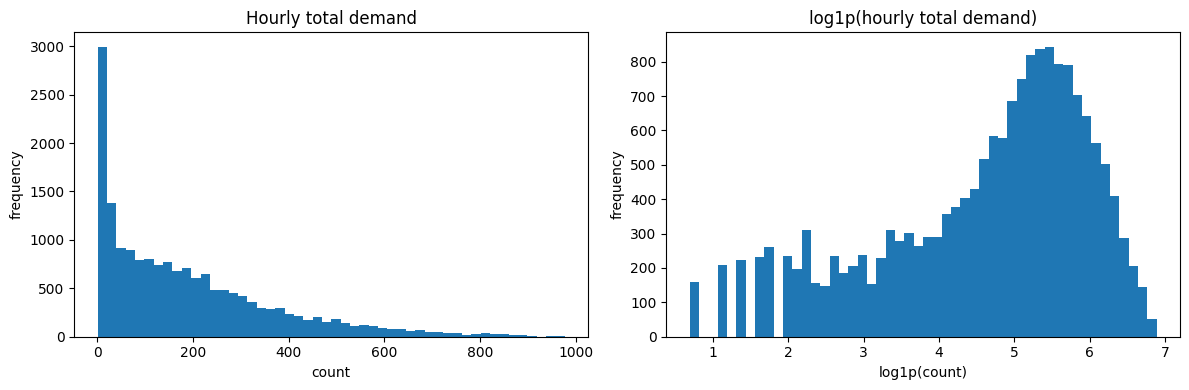

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["count"], bins=50)
axes[0].set_title("Hourly total demand")
axes[0].set_xlabel("count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(df["count"]), bins=50)
axes[1].set_title("log1p(hourly total demand)")
axes[1].set_xlabel("log1p(count)")
axes[1].set_ylabel("frequency")
plt.tight_layout()
plt.show()

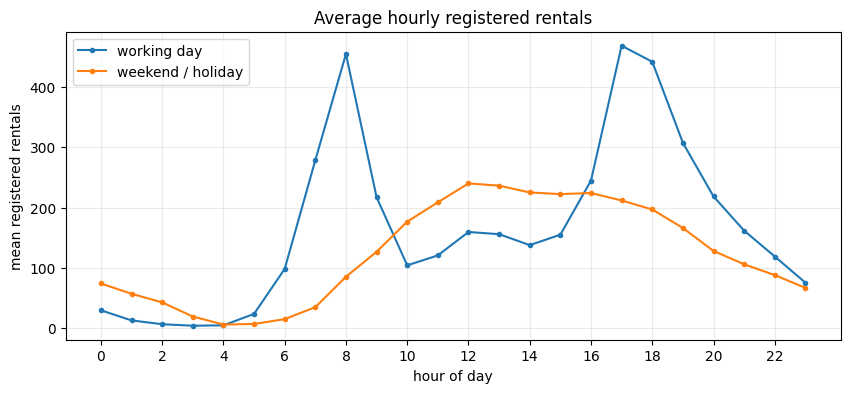

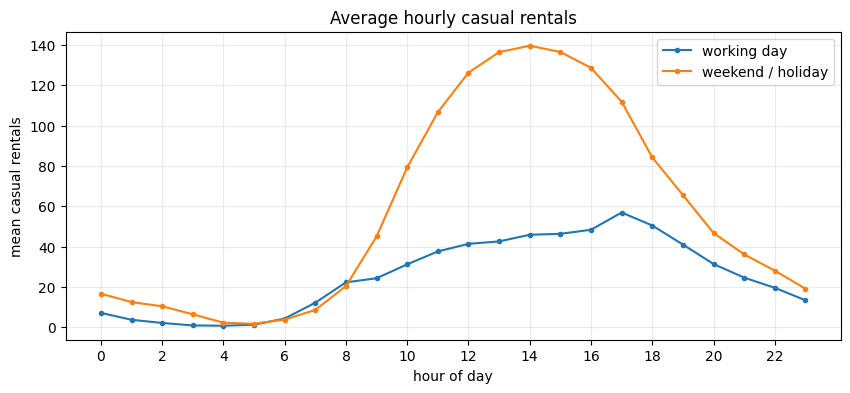

In [ ]:

hour_user = (
    df.groupby(["hour", "workingday"], as_index=False)[["casual", "registered", "count"]]
      .mean()
)

for target in ["registered", "casual"]:
    plt.figure(figsize=(10, 4))
    for wd, label in [(1, "working day"), (0, "weekend / holiday")]:
        sub = hour_user[hour_user["workingday"].eq(wd)]
        plt.plot(sub["hour"], sub[target], marker="o", markersize=3, label=label)
    plt.title(f"Average hourly {target} rentals")
    plt.xlabel("hour of day")
    plt.ylabel(f"mean {target} rentals")
    plt.xticks(range(0, 24, 2))
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

,weather,rows,mean_count,median_count,mean_casual,mean_registered,mean_temp_c
0,1,11413,204.8693,159.0000,40.5454,164.3238,16.0195
1,2,4544,175.1655,133.0000,29.5953,145.5702,14.2989
2,3,1419,111.5793,63.0000,16.0557,95.5236,13.4643
3,4,3,74.3333,36.0000,2.6667,71.6667,0.7733


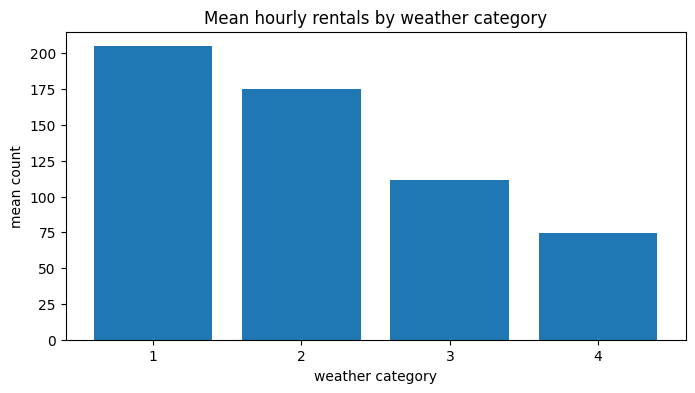

Caution: these are uncontrolled group means. Weather is confounded with season, hour and other conditions.


In [ ]:

weather_summary = (
    df.groupby("weather", as_index=False, observed=True)
      .agg(
          rows=("count", "size"),
          mean_count=("count", "mean"),
          median_count=("count", "median"),
          mean_casual=("casual", "mean"),
          mean_registered=("registered", "mean"),
          mean_temp_c=("temp_c", "mean"),
      )
)
display(weather_summary)
weather_summary.to_csv(OUTPUT_DIR / "weather_descriptive_summary.csv", index=False)

plt.figure(figsize=(8, 4))
plt.bar(weather_summary["weather"].astype(str), weather_summary["mean_count"])
plt.title("Mean hourly rentals by weather category")
plt.xlabel("weather category")
plt.ylabel("mean count")
plt.show()

print("Caution: these are uncontrolled group means. Weather is confounded with season, hour and other conditions.")

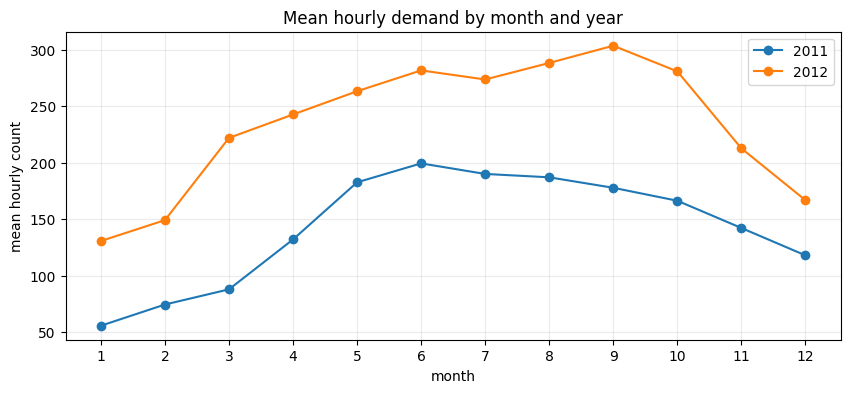

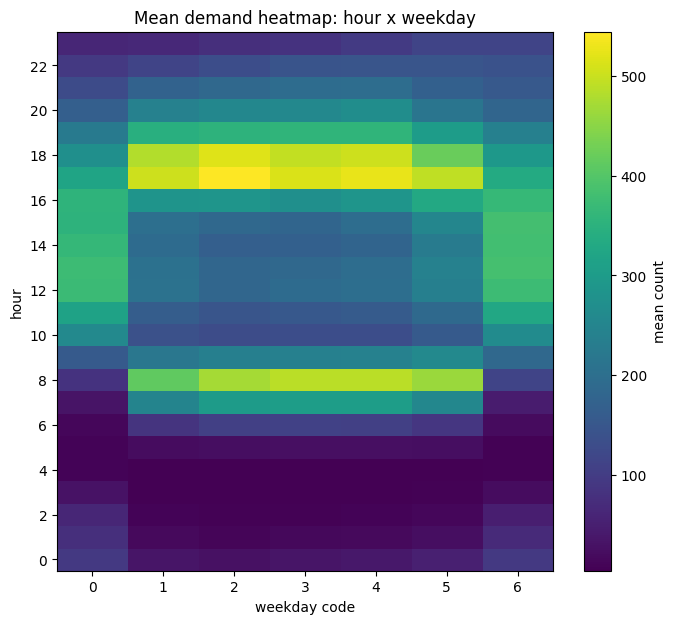

In [ ]:

month_year = df.groupby(["year", "month"], as_index=False)["count"].mean()
plt.figure(figsize=(10, 4))
for yr in sorted(month_year["year"].unique()):
    sub = month_year[month_year["year"].eq(yr)]
    plt.plot(sub["month"], sub["count"], marker="o", label=str(yr))
plt.title("Mean hourly demand by month and year")
plt.xlabel("month")
plt.ylabel("mean hourly count")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.25)
plt.show()

heat = df.pivot_table(index="hour", columns="weekday", values="count", aggfunc="mean")
plt.figure(figsize=(8, 7))
plt.imshow(heat.values, aspect="auto", origin="lower")
plt.colorbar(label="mean count")
plt.xticks(range(len(heat.columns)), heat.columns)
plt.yticks(range(0, 24, 2), range(0, 24, 2))
plt.xlabel("weekday code")
plt.ylabel("hour")
plt.title("Mean demand heatmap: hour x weekday")
plt.show()

count   731.0000
mean     23.7743
std       1.3507
min       1.0000
25%      24.0000
50%      24.0000
75%      24.0000
max      24.0000
Name: recorded_hours, dtype: float64
Days with fewer than 24 rows: 76


,recorded_hours
date,
2012-10-29,1
2011-01-27,8
2012-10-30,11
2011-01-18,12
2011-01-26,16
2011-08-28,17
2011-02-22,18
2011-08-27,18
2011-01-03,22


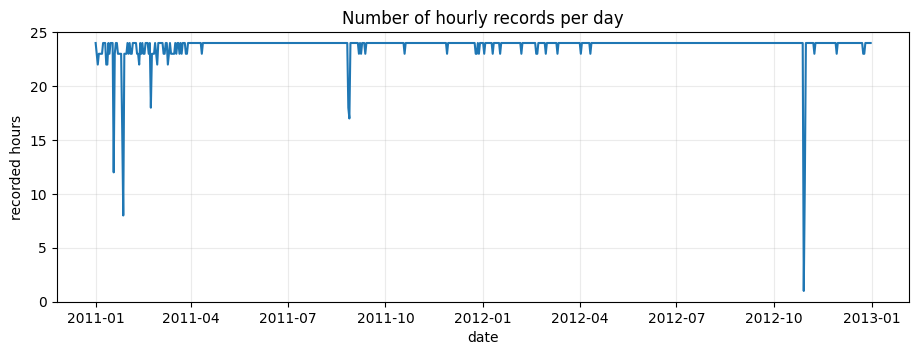

In [ ]:

hours_per_day = df.groupby("date").size().rename("recorded_hours")
print(hours_per_day.describe())
print("Days with fewer than 24 rows:", int((hours_per_day < 24).sum()))
display(hours_per_day.nsmallest(10).to_frame())

plt.figure(figsize=(11, 3.5))
plt.plot(hours_per_day.index, hours_per_day.values)
plt.ylim(0, 25)
plt.title("Number of hourly records per day")
plt.xlabel("date")
plt.ylabel("recorded hours")
plt.grid(alpha=0.25)
plt.show()

In [ ]:

vif_cols = ["temp", "atemp", "humidity", "windspeed"]
X_vif = sm.add_constant(df[vif_cols].astype(float))
vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
display(vif_table)
vif_table.to_csv(OUTPUT_DIR / "vif_table.csv", index=False)

,variable,VIF
0,const,29.9366
1,temp,43.5503
2,atemp,43.6513
3,humidity,1.1006
4,windspeed,1.1563


In [ ]:
reg_df = df.copy()
reg_df["log_count"] = np.log1p(reg_df["count"])
reg_df["temp_c_centered"] = reg_df["temp_c"] - reg_df["temp_c"].mean()
reg_df["humidity_10pct"] = reg_df["humidity_pct"] / 10.0
reg_df["windspeed_10units"] = reg_df["windspeed_original_scale"] / 10.0

ols_formula = (
    "log_count ~ C(hour) * workingday + holiday + C(month) + C(year) + "
    "C(weather_group) + temp_c_centered + I(temp_c_centered ** 2) + "
    "humidity_10pct + windspeed_10units"
)

ols_hac = smf.ols(ols_formula, data=reg_df).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 24}
)

print("Log-OLS with HAC standard errors")
print("R-squared:", round(ols_hac.rsquared, 4))
print("Adjusted R-squared:", round(ols_hac.rsquared_adj, 4))
print("N:", int(ols_hac.nobs))

selected_patterns = [
    "C(year)", "C(weather_group)", "temp_c_centered", "humidity_10pct", "windspeed_10units", "workingday"
]
selected_terms = [
    term for term in ols_hac.params.index
    if any(pattern in term for pattern in selected_patterns)
]
regression_terms = pd.DataFrame({
    "term": selected_terms,
    "coef_log_scale": ols_hac.params[selected_terms],
    "std_error_HAC": ols_hac.bse[selected_terms],
    "p_value": ols_hac.pvalues[selected_terms],
})
regression_terms["approx_percent_change"] = 100 * (np.exp(regression_terms["coef_log_scale"]) - 1)
display(regression_terms)
regression_terms.to_csv(OUTPUT_DIR / "regression_selected_terms.csv", index=False)

Log-OLS with HAC standard errors
R-squared: 0.9292
Adjusted R-squared: 0.9289
N: 17379


,term,coef_log_scale,std_error_HAC,p_value,approx_percent_change
C(year)[T.2012],C(year)[T.2012],0.4462,0.0165,0.0000,56.2416
C(weather_group)[T.mist_cloudy],C(weather_group)[T.mist_cloudy],-0.0654,0.0132,0.0000,-6.3320
C(weather_group)[T.precipitation],C(weather_group)[T.precipitation],-0.5852,0.0402,0.0000,-44.3016
workingday,workingday,-0.9352,0.0314,0.0000,-60.7493
C(hour)[T.1]:workingday,C(hour)[T.1]:workingday,-0.5142,0.0285,0.0000,-40.2048
C(hour)[T.2]:workingday,C(hour)[T.2]:workingday,-0.8554,0.0353,0.0000,-57.4872
C(hour)[T.3]:workingday,C(hour)[T.3]:workingday,-0.5938,0.0398,0.0000,-44.7750
C(hour)[T.4]:workingday,C(hour)[T.4]:workingday,0.5429,0.0455,0.0000,72.0905
C(hour)[T.5]:workingday,C(hour)[T.5]:workingday,1.9515,0.0479,0.0000,603.9498
C(hour)[T.6]:workingday,C(hour)[T.6]:workingday,2.7359,0.0488,0.0000,"1,442.4300"


In [ ]:

count_formula = (
    "count ~ C(hour) * workingday + holiday + C(month) + C(year) + "
    "C(weather_group) + temp_c_centered + I(temp_c_centered ** 2) + "
    "humidity_10pct + windspeed_10units"
)

poisson_glm = smf.glm(
    count_formula,
    data=reg_df,
    family=sm.families.Poisson()
).fit(maxiter=100)

poisson_dispersion = float(poisson_glm.pearson_chi2 / poisson_glm.df_resid)
print(f"Poisson Pearson dispersion: {poisson_dispersion:.3f}")
print("A value materially above 1 indicates overdispersion relative to Poisson.")

mu = reg_df["count"].mean()
var = reg_df["count"].var(ddof=1)
alpha_mom = max((var - mu) / (mu ** 2), 1e-8)

nb_glm = smf.glm(
    count_formula,
    data=reg_df,
    family=sm.families.NegativeBinomial(alpha=alpha_mom)
).fit(maxiter=100)

print(f"Negative-Binomial alpha (method of moments): {alpha_mom:.4f}")
print(f"Poisson AIC: {poisson_glm.aic:,.1f}")
print(f"NB-GLM AIC: {nb_glm.aic:,.1f}")

Poisson Pearson dispersion: 13.048
A value materially above 1 indicates overdispersion relative to Poisson.
Negative-Binomial alpha (method of moments): 0.9113
Poisson AIC: 336,572.5
NB-GLM AIC: 194,084.4


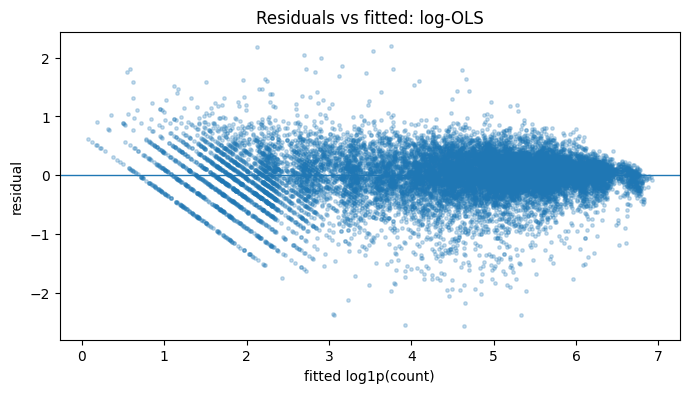

Residual autocorrelation at lag 1: 0.6020
Residual autocorrelation at lag 24: 0.2339
Residual autocorrelation at lag 168: 0.1716


In [ ]:

fitted = ols_hac.fittedvalues
resid = ols_hac.resid

plt.figure(figsize=(8, 4))
plt.scatter(fitted, resid, s=6, alpha=0.25)
plt.axhline(0, linewidth=1)
plt.xlabel("fitted log1p(count)")
plt.ylabel("residual")
plt.title("Residuals vs fitted: log-OLS")
plt.show()

acf_lags = [1, 24, 168]
for lag in acf_lags:
    corr = pd.Series(resid).autocorr(lag=lag)
    print(f"Residual autocorrelation at lag {lag}: {corr:.4f}")

In [ ]:

df["split_label"] = np.where(df["day"].le(20), "train_1_20", "test_21_eom")
split_counts = df["split_label"].value_counts().rename_axis("split").reset_index(name="rows")
display(split_counts)

split_by_month = (
    df.groupby(["period", "split_label"], observed=True)
      .size()
      .unstack(fill_value=0)
)
display(split_by_month)
split_by_month.to_csv(OUTPUT_DIR / "split_by_month.csv")

,split,rows
0,train_1_20,11460
1,test_21_eom,5919


split_label,test_21_eom,train_1_20
period,,
2011-01,233,455
2011-02,180,469
2011-03,260,470
2011-04,240,479
2011-05,264,480
2011-06,240,480
2011-07,264,480
2011-08,251,480
2011-09,240,477


In [ ]:
FEATURE_ORIGIN = df["datetime"].min().normalize()


def build_features(frame, include_weather=False):
    """Build features available from calendar information, optionally plus weather covariates."""
    X = pd.DataFrame(index=frame.index)
    dt = frame["datetime"]
    hour = dt.dt.hour.astype(int)
    dow = frame["weekday"].astype(int)
    month = dt.dt.month.astype(int)
    doy = dt.dt.dayofyear.astype(int)


    X["year_code"] = frame["year_code"].astype(int)
    X["month"] = month
    X["hour"] = hour
    X["weekday"] = dow
    X["season_code"] = frame["season"].astype(int)
    X["holiday"] = frame["holiday"].astype(int)
    X["workingday"] = frame["workingday"].astype(int)


    X["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    X["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    X["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    X["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    X["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
    X["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)
    X["doy_sin"] = np.sin(2 * np.pi * (doy - 1) / 365.25)
    X["doy_cos"] = np.cos(2 * np.pi * (doy - 1) / 365.25)


    X["trend_years"] = (dt - FEATURE_ORIGIN).dt.total_seconds() / (365.25 * 24 * 3600)


    X["am_commute"] = ((frame["workingday"].eq(1)) & hour.between(7, 9)).astype(int)
    X["pm_commute"] = ((frame["workingday"].eq(1)) & hour.between(16, 19)).astype(int)
    X["nonwork_daytime"] = ((frame["workingday"].eq(0)) & hour.between(10, 18)).astype(int)

    if include_weather:

        X["weather"] = frame["weather"].astype(int)
        X["temp"] = frame["temp"].astype(float)
        X["humidity"] = frame["humidity"].astype(float)
        X["windspeed"] = frame["windspeed"].astype(float)


    return X.astype(float)

In [ ]:

def resolve_xgb_device():
    try:
        import torch
        if not torch.cuda.is_available():
            return "cpu"
    except Exception:
        return "cpu"

    try:
        X_tiny = np.array([[0.0], [1.0], [2.0], [3.0]], dtype=float)
        y_tiny = np.array([0.0, 1.0, 1.5, 2.0], dtype=float)
        probe = XGBRegressor(
            n_estimators=2,
            max_depth=2,
            tree_method="hist",
            device="cuda",
            objective="reg:squarederror",
            random_state=SEED,
            verbosity=0,
        )
        probe.fit(X_tiny, y_tiny)
        return "cuda"
    except Exception as exc:
        print("GPU detected but XGBoost CUDA probe failed; falling back to CPU:", type(exc).__name__)
        return "cpu"


XGB_DEVICE = resolve_xgb_device()
print("XGBoost device:", XGB_DEVICE)


def make_xgb_model():
    return XGBRegressor(
        n_estimators=320,
        max_depth=8,
        learning_rate=0.04,
        min_child_weight=5,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.05,
        reg_lambda=3.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        device=XGB_DEVICE,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )


def xgb_log_fit_predict(train_frame, test_frame, target, include_weather=False):
    X_train = build_features(train_frame, include_weather=include_weather)
    X_test = build_features(test_frame, include_weather=include_weather)
    y_train = np.log1p(train_frame[target].astype(float).to_numpy())

    model = make_xgb_model()
    model.fit(X_train, y_train)
    pred = np.expm1(model.predict(X_test))
    pred = np.clip(pred, 0.0, None)
    return pred, model

XGBoost device: cuda


In [ ]:
def profile_baseline(train_frame, test_frame, shrinkage=4.0):
    """
    A leakage-safe current-month seasonal profile.

    Fine profile: hour x weekday on days 1-20 of the current month.
    Coarse prior: hour x workingday on days 1-20 of the current month.
    Predictions are shrinkage estimates on log1p(count).
    """
    test_period = test_frame["period"].iloc[0]
    current = train_frame[train_frame["period"].eq(test_period)].copy()
    if current.empty:
        current = train_frame.copy()

    current["log_target"] = np.log1p(current["count"].astype(float))

    coarse = (
        current.groupby(["hour", "workingday"], observed=True)["log_target"]
        .agg(["mean", "count"])
    )
    fine = (
        current.groupby(["hour", "weekday"], observed=True)["log_target"]
        .agg(["mean", "count"])
    )
    hour_only = current.groupby("hour", observed=True)["log_target"].mean()
    global_mean = float(current["log_target"].mean())

    preds = []
    for row in test_frame.itertuples(index=False):
        coarse_key = (int(row.hour), int(row.workingday))
        fine_key = (int(row.hour), int(row.weekday))

        if coarse_key in coarse.index:
            coarse_mean = float(coarse.loc[coarse_key, "mean"])
        elif int(row.hour) in hour_only.index:
            coarse_mean = float(hour_only.loc[int(row.hour)])
        else:
            coarse_mean = global_mean

        if fine_key in fine.index:
            fine_mean = float(fine.loc[fine_key, "mean"])
            fine_n = float(fine.loc[fine_key, "count"])
            pred_log = (fine_n * fine_mean + shrinkage * coarse_mean) / (fine_n + shrinkage)
        else:
            pred_log = coarse_mean

        preds.append(max(np.expm1(pred_log), 0.0))

    return np.asarray(preds, dtype=float)

In [ ]:

periods = sorted(df.loc[df["day"].ge(21), "period"].unique())
window_outputs = []
last_fitted_models = {}

for i, period in enumerate(periods, start=1):
    period = pd.Period(period, freq="M")
    test_mask = df["period"].eq(period) & df["day"].ge(21)
    test_window = df.loc[test_mask].copy()
    if test_window.empty:
        continue

    forecast_origin = period.start_time + pd.Timedelta(days=20)  # 21st 00:00
    train_mask = df["day"].le(20) & df["datetime"].lt(forecast_origin)
    train_window = df.loc[train_mask].copy()


    assert train_window["datetime"].max() < test_window["datetime"].min()
    assert train_window["day"].le(20).all()
    assert test_window["day"].ge(21).all()
    assert not (train_window["period"] > period).any()

    out = test_window[[
        "datetime", "period", "year", "month", "day", "hour", "weekday",
        "workingday", "weather", "count"
    ]].copy()

    out["profile_baseline"] = profile_baseline(train_window, test_window)

    pred_direct, model_direct = xgb_log_fit_predict(
        train_window, test_window, target="count", include_weather=False
    )
    out["xgb_strict_direct"] = pred_direct

    pred_casual, model_casual = xgb_log_fit_predict(
        train_window, test_window, target="casual", include_weather=False
    )
    pred_registered, model_registered = xgb_log_fit_predict(
        train_window, test_window, target="registered", include_weather=False
    )
    out["xgb_strict_segmented"] = np.clip(pred_casual + pred_registered, 0.0, None)

    pred_weather, model_weather = xgb_log_fit_predict(
        train_window, test_window, target="count", include_weather=True
    )
    out["xgb_weather_conditional"] = pred_weather

    window_outputs.append(out)

    if i == len(periods):
        last_fitted_models = {
            "strict_direct": model_direct,
            "strict_casual": model_casual,
            "strict_registered": model_registered,
            "weather_conditional": model_weather,
        }

    if i == 1 or i % 6 == 0 or i == len(periods):
        print(f"Completed {i:02d}/{len(periods)} windows: {period}")

predictions = pd.concat(window_outputs, ignore_index=True)
print("Evaluation rows:", len(predictions))
display(predictions.head())
predictions.to_csv(OUTPUT_DIR / "forecast_predictions.csv", index=False)

Completed 01/24 windows: 2011-01
Completed 06/24 windows: 2011-06
Completed 12/24 windows: 2011-12
Completed 18/24 windows: 2012-06
Completed 24/24 windows: 2012-12
Evaluation rows: 5919


,datetime,period,year,month,day,hour,weekday,workingday,weather,count,profile_baseline,xgb_strict_direct,xgb_strict_segmented,xgb_weather_conditional
0,2011-01-21 00:00:00,2011-01,2011,1,21,0,5,1,2,21,9.8705,12.2960,12.5662,12.9761
1,2011-01-21 01:00:00,2011-01,2011,1,21,1,5,1,2,6,4.3633,6.1766,5.8835,6.5647
2,2011-01-21 02:00:00,2011-01,2011,1,21,2,5,1,3,2,1.5029,2.2493,2.3389,2.4104
3,2011-01-21 03:00:00,2011-01,2011,1,21,3,5,1,3,1,1.2974,1.4033,1.5739,2.8404
4,2011-01-21 04:00:00,2011-01,2011,1,21,4,5,1,2,1,1.5711,1.6899,1.6006,3.5436


In [ ]:
def metric_dict(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0.0, None)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "RMSLE": math.sqrt(mean_squared_log_error(y_true, y_pred)),
        "WAPE": np.abs(y_true - y_pred).sum() / np.maximum(np.abs(y_true).sum(), 1e-12),
    }

model_columns = [
    "profile_baseline",
    "xgb_strict_direct",
    "xgb_strict_segmented",
    "xgb_weather_conditional",
]

aggregate_rows = []
for model_name in model_columns:
    row = {"model": model_name}
    row.update(metric_dict(predictions["count"], predictions[model_name]))
    aggregate_rows.append(row)
aggregate_metrics = pd.DataFrame(aggregate_rows).sort_values("RMSLE").reset_index(drop=True)

display(aggregate_metrics)
aggregate_metrics.to_csv(OUTPUT_DIR / "forecast_metrics_aggregate.csv", index=False)

,model,MAE,RMSE,RMSLE,WAPE
0,xgb_weather_conditional,37.1640,61.3886,0.4449,0.2013
1,xgb_strict_segmented,51.2315,83.0885,0.5363,0.2776
2,profile_baseline,48.7409,83.0023,0.5369,0.2641
3,xgb_strict_direct,51.8619,84.9854,0.5385,0.2810


In [ ]:

monthly_rows = []
for period, group in predictions.groupby("period", observed=True):
    for model_name in model_columns:
        row = {"period": str(period), "model": model_name, "n": len(group)}
        row.update(metric_dict(group["count"], group[model_name]))
        monthly_rows.append(row)
monthly_metrics = pd.DataFrame(monthly_rows)
monthly_metrics.to_csv(OUTPUT_DIR / "forecast_metrics_monthly.csv", index=False)

print("Worst 5 RMSLE windows for strict segmented model:")
display(
    monthly_metrics[monthly_metrics["model"].eq("xgb_strict_segmented")]
    .sort_values("RMSLE", ascending=False)
    .head(5)
)

Worst 5 RMSLE windows for strict segmented model:


,period,model,n,MAE,RMSE,RMSLE,WAPE
94,2012-12,xgb_strict_segmented,262,84.4678,130.2687,1.0435,1.0739
46,2011-12,xgb_strict_segmented,261,54.5368,77.1793,0.7997,0.6357
14,2011-04,xgb_strict_segmented,240,76.0247,111.6836,0.7274,0.4515
62,2012-04,xgb_strict_segmented,240,70.1958,120.8414,0.7246,0.3366
22,2011-06,xgb_strict_segmented,240,50.3944,74.8844,0.6852,0.2432


In [ ]:

slice_rows = []
for year, group in predictions.groupby("year"):
    for model_name in model_columns:
        row = {"slice": f"year_{year}", "model": model_name}
        row.update(metric_dict(group["count"], group[model_name]))
        slice_rows.append(row)

peak_mask = predictions["workingday"].eq(1) & predictions["hour"].isin([7, 8, 9, 16, 17, 18, 19])
peak_group = predictions.loc[peak_mask]
for model_name in model_columns:
    row = {"slice": "workingday_commute_hours", "model": model_name}
    row.update(metric_dict(peak_group["count"], peak_group[model_name]))
    slice_rows.append(row)

slice_metrics = pd.DataFrame(slice_rows)
display(slice_metrics)
slice_metrics.to_csv(OUTPUT_DIR / "forecast_metrics_slices.csv", index=False)

,slice,model,MAE,RMSE,RMSLE,WAPE
0,year_2011,profile_baseline,39.2118,65.0509,0.5141,0.2758
1,year_2011,xgb_strict_direct,43.4980,69.7818,0.5500,0.3060
2,year_2011,xgb_strict_segmented,44.1876,70.3154,0.5566,0.3108
3,year_2011,xgb_weather_conditional,34.1379,54.8177,0.4610,0.2401
4,year_2012,profile_baseline,58.1198,97.4950,0.5584,0.2568
5,year_2012,xgb_strict_direct,60.0940,97.6650,0.5269,0.2655
6,year_2012,xgb_strict_segmented,58.1644,93.9802,0.5154,0.2570
7,year_2012,xgb_weather_conditional,40.1425,67.2318,0.4285,0.1774
8,workingday_commute_hours,profile_baseline,80.9056,119.4736,0.4771,0.2156
9,workingday_commute_hours,xgb_strict_direct,88.8103,124.0849,0.4798,0.2366


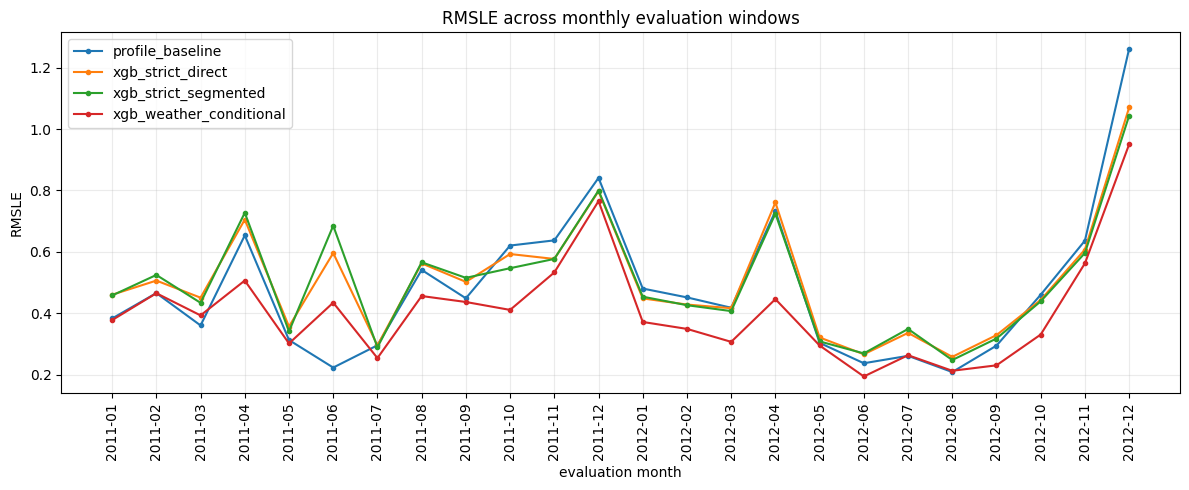

In [ ]:

plt.figure(figsize=(12, 5))
for model_name in model_columns:
    sub = monthly_metrics[monthly_metrics["model"].eq(model_name)].copy()
    plt.plot(sub["period"], sub["RMSLE"], marker="o", markersize=3, label=model_name)
plt.xticks(rotation=90)
plt.ylabel("RMSLE")
plt.xlabel("evaluation month")
plt.title("RMSLE across monthly evaluation windows")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

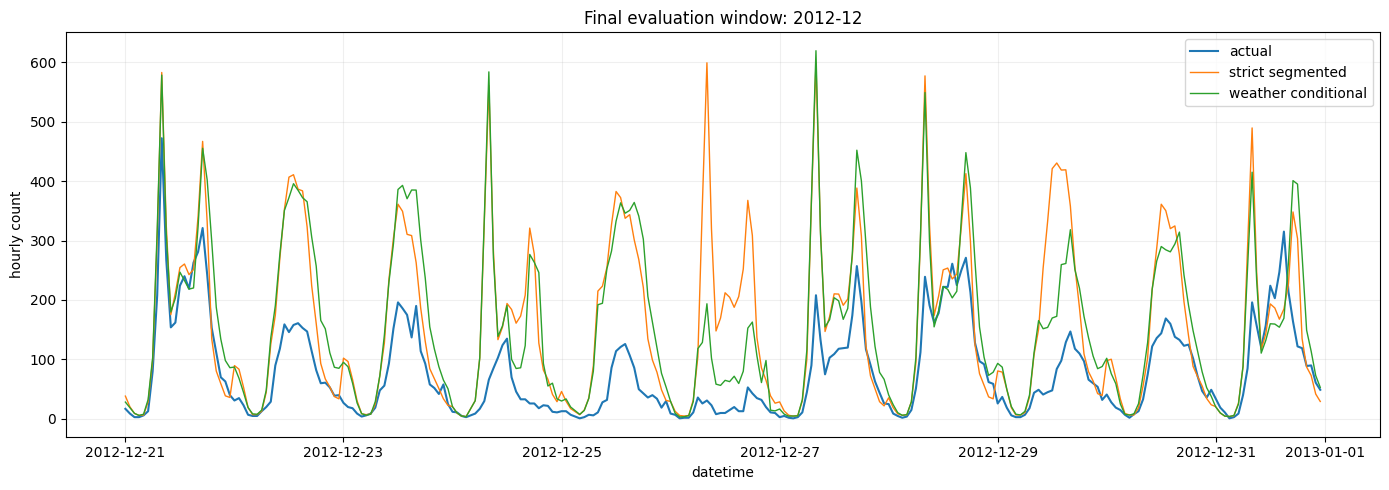

In [ ]:

last_period = predictions["period"].iloc[-1]
last = predictions[predictions["period"].eq(last_period)].copy()
plt.figure(figsize=(14, 5))
plt.plot(last["datetime"], last["count"], label="actual", linewidth=1.5)
plt.plot(last["datetime"], last["xgb_strict_segmented"], label="strict segmented", linewidth=1.0)
plt.plot(last["datetime"], last["xgb_weather_conditional"], label="weather conditional", linewidth=1.0)
plt.title(f"Final evaluation window: {last_period}")
plt.xlabel("datetime")
plt.ylabel("hourly count")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:

def importance_table(model, feature_names):
    return (
        pd.DataFrame({"feature": feature_names, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

strict_names = build_features(df.head(2), include_weather=False).columns.tolist()
weather_names = build_features(df.head(2), include_weather=True).columns.tolist()

strict_imp = importance_table(last_fitted_models["strict_direct"], strict_names)
weather_imp = importance_table(last_fitted_models["weather_conditional"], weather_names)

print("Top strict-model features")
display(strict_imp.head(15))
print("Top weather-conditional features")
display(weather_imp.head(15))

strict_imp.to_csv(OUTPUT_DIR / "feature_importance_strict.csv", index=False)
weather_imp.to_csv(OUTPUT_DIR / "feature_importance_weather_conditional.csv", index=False)

Top strict-model features


,feature,importance
0,hour,0.2104
1,am_commute,0.1273
2,season_code,0.1141
3,workingday,0.1003
4,pm_commute,0.0999
5,nonwork_daytime,0.0795
6,hour_sin,0.0732
7,hour_cos,0.0598
8,trend_years,0.0363
9,month,0.0259


Top weather-conditional features


,feature,importance
0,hour,0.2083
1,am_commute,0.1092
2,hour_cos,0.1012
3,pm_commute,0.1006
4,workingday,0.0959
5,hour_sin,0.0926
6,nonwork_daytime,0.0864
7,season_code,0.0430
8,trend_years,0.0425
9,year_code,0.0204


In [ ]:
def df_to_markdown_simple(table, float_digits=4):
    t = table.copy()
    for c in t.select_dtypes(include=[np.number]).columns:
        t[c] = t[c].map(lambda v: f"{v:.{float_digits}f}")
    headers = list(t.columns)
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    for _, row in t.iterrows():
        lines.append("| " + " | ".join(str(row[h]) for h in headers) + " |")
    return "\n".join(lines)

best_strict_row = (
    aggregate_metrics[aggregate_metrics["model"].isin(["xgb_strict_direct", "xgb_strict_segmented"])]
    .sort_values("RMSLE")
    .iloc[0]
)
best_strict_model = best_strict_row["model"]

weather4_n = int(df["weather"].eq(4).sum())
missing_hour_n = len(missing_timestamps)
daily_mismatch_n = int(reconciliation["difference"].ne(0).sum())

metric_md = df_to_markdown_simple(aggregate_metrics, 4)
worst_months = (
    monthly_metrics[monthly_metrics["model"].eq(best_strict_model)]
    .sort_values("RMSLE", ascending=False)
    .head(5)[["period", "n", "MAE", "RMSE", "RMSLE", "WAPE"]]
)
worst_md = df_to_markdown_simple(worst_months, 4)

report_text = f"""# Capital Bikeshare Demand Analysis & Forecasting Report

## Executive summary

The analysis uses the UCI Capital Bikeshare hourly data and respects the required day-of-month partition (training: 1-20; evaluation: 21-end). The forecasting evaluation is performed month-by-month so future months never enter the training data for an earlier evaluation window.

The best strict ex-ante model by aggregate RMSLE in this run was **{best_strict_model}** with RMSLE **{best_strict_row['RMSLE']:.4f}**, RMSE **{best_strict_row['RMSE']:.2f}**, MAE **{best_strict_row['MAE']:.2f}**, and WAPE **{best_strict_row['WAPE']:.2%}**.

## 1. Data quality and exploratory findings

- Hourly rows: **{len(df):,}** from {df['datetime'].min()} through {df['datetime'].max()}.
- Mean hourly total demand: **{df['count'].mean():.2f}**; median: **{df['count'].median():.0f}**; maximum: **{df['count'].max():.0f}**.
- Registered riders account for **{registered_share:.1%}** of all rentals by volume.
- `count = casual + registered` for all supplied rows. These components were therefore excluded as predictors of total count.
- The complete hourly calendar contains **{missing_hour_n}** timestamps not represented as rows in `hour.csv`; this is a time-index irregularity even though the CSV has no missing cells.
- Daily aggregation reconciliation mismatches: **{daily_mismatch_n}** days.
- Extreme weather category 4 appears only **{weather4_n}** times, making a standalone regression coefficient unstable.
- Correlation between normalized `temp` and `atemp`: **{temp_atemp_corr:.4f}**, supporting removal of one of them from the inferential regression.
- Raw count variance/mean ratio: **{overdispersion_raw:.2f}**, indicating substantial overdispersion.

Behaviorally, registered users show much stronger working-day commute peaks, while casual demand is relatively more concentrated in daytime and non-working periods. Demand also changes substantially by month/year, which makes chronology-aware validation essential.

## 2. Statistical / regression analysis

The primary inferential model is OLS on `log1p(count)` with categorical hour, an hour-by-working-day interaction, month/year controls, grouped weather, nonlinear temperature, humidity and wind speed. `atemp` is omitted due to its redundancy with temperature. HAC/Newey-West standard errors with 24 lags are used to reduce sensitivity to serial correlation.

The raw count distribution is not well described by a simple Poisson variance model. The fitted Poisson Pearson dispersion was **{poisson_dispersion:.3f}**. A Negative-Binomial GLM was therefore fit as a robustness model using alpha={alpha_mom:.4f}. Coefficients should be interpreted as conditional associations, not causal effects.

## 3. Forecasting design

For each month, the forecast origin is the start of the 21st. Training data contain only permitted day 1-20 rows timestamped before that origin. Evaluation data contain day 21 through month-end rows for that month. Models are retrained at every monthly origin.

Strict models use only calendar/time information that is known before the window. A weather-conditional model is reported separately and should only be treated as deployable if future weather covariates are supplied as genuine forecasts.

### Aggregate forecasting metrics

{metric_md}

### Most difficult windows for the best strict model

{worst_md}

## 4. Model-selection interpretation

The current-month profile baseline provides a strong seasonal reference. XGBoost captures nonlinear interactions among hour, working-day status, weekday, annual seasonality and system growth. The segmented architecture predicts casual and registered demand separately and then sums them, which is statistically legitimate because those two variables are training targets rather than predictors.

The weather-conditional result should be compared with the strict score to quantify the potential value of weather information, but it is not a fair ex-ante score unless those weather values would truly be known before the forecast window.

## 5. Limitations

1. The supplied data are observational, so regression coefficients are not causal.
2. The hourly time index is irregular; evaluation here follows the rows supplied by the dataset rather than inventing missing weather covariates.
3. The most severe weather class is too rare for reliable standalone inference.
4. The system changes materially between 2011 and 2012, so distribution shift is important.
5. Monthly multi-day forecasting is harder than one-step-ahead forecasting because actual targets from inside the evaluation window are intentionally not fed back as lag features.

## Reproducibility

Random seed: {SEED}. XGBoost device used: {XGB_DEVICE}. Hyperparameters were fixed before test scoring and were not tuned using evaluation-window outcomes.
"""

report_path = OUTPUT_DIR / "capital_bikeshare_report.md"
report_path.write_text(report_text, encoding="utf-8")
print("Wrote:", report_path)
print(report_text[:3500])

Wrote: bikeshare_outputs/capital_bikeshare_report.md
# Capital Bikeshare Demand Analysis & Forecasting Report

## Executive summary

The analysis uses the UCI Capital Bikeshare hourly data and respects the required day-of-month partition (training: 1-20; evaluation: 21-end). The forecasting evaluation is performed month-by-month so future months never enter the training data for an earlier evaluation window.

The best strict ex-ante model by aggregate RMSLE in this run was **xgb_strict_segmented** with RMSLE **0.5363**, RMSE **83.09**, MAE **51.23**, and WAPE **27.76%**.

## 1. Data quality and exploratory findings

- Hourly rows: **17,379** from 2011-01-01 00:00:00 through 2012-12-31 23:00:00.
- Mean hourly total demand: **189.46**; median: **142**; maximum: **977**.
- Registered riders account for **81.2%** of all rentals by volume.
- `count = casual + registered` for all supplied rows. These components were therefore excluded as predictors of total count.
- The complete hourly calen

In [ ]:
print("Generated files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path)


Generated files:
 - bikeshare_outputs/capital_bikeshare_report.md
 - bikeshare_outputs/data_integrity_audit.csv
 - bikeshare_outputs/descriptive_statistics.csv
 - bikeshare_outputs/feature_importance_strict.csv
 - bikeshare_outputs/feature_importance_weather_conditional.csv
 - bikeshare_outputs/forecast_metrics_aggregate.csv
 - bikeshare_outputs/forecast_metrics_monthly.csv
 - bikeshare_outputs/forecast_metrics_slices.csv
 - bikeshare_outputs/forecast_predictions.csv
 - bikeshare_outputs/regression_selected_terms.csv
 - bikeshare_outputs/split_by_month.csv
 - bikeshare_outputs/vif_table.csv
 - bikeshare_outputs/weather_descriptive_summary.csv
